# Olist EDA con DuckClaw

Análisis de comportamiento de clientes y tendencias de ventas usando **DuckClaw**, DuckDB + consultas en lenguaje natural y **gráficas** con matplotlib/seaborn.

**LLM:** Groq (`provider="groq"`), **DeepSeek** (`provider="deepseek"`), o **MLX local** (`provider="mlx"`). Groq y DeepSeek requieren su `API_KEY` (`GROQ_API_KEY`, `DEEPSEEK_API_KEY`). Para MLX, arranca antes el motor con PM2: `pm2 start ecosystem.config.cjs` (puerto 8080). Ver README y `docs/pm2-migration.md`.

## Resumen: Instalación, configuración y uso de DuckClaw

### a. Instalación

**Prerrequisitos:** macOS (Apple Silicon), CMake ≥ 3.18, DuckDB, Pybind11.

```bash
# Desde la raíz del repo
git clone https://github.com/Arevalojj2020/duckclaw.git
cd duckclaw

# Con pip
pip install cmake pybind11
pip install -e . --no-build-isolation

# Con uv (recomendado)
uv pip install -e .

# Para LLM Groq
pip install -e ".[groq]"
```

La primera compilación tarda ~5–7 min (descarga y compila DuckDB).

### b. Configuración

- **Datos Olist:** Coloca los CSV en `data/` (olist_orders_dataset.csv, olist_customers_dataset.csv, etc.).
- **LLM (lenguaje natural):** Elige un proveedor y configura su API key en `.env` o variables de entorno:
  - **Groq:** `GROQ_API_KEY` → `export GROQ_API_KEY='tu-api-key'`
  - **DeepSeek:** `DEEPSEEK_API_KEY` → `export DEEPSEEK_API_KEY='tu-api-key'`
  - **MLX (local):** Arranca el motor con `pm2 start ecosystem.config.cjs` (puerto 8080).

### c. Uso básico

```python
import duckclaw
from duckclaw.bi import load_olist_data, ask_bi, get_top_sellers

db = duckclaw.DuckClaw(str(DB_PATH))
load_olist_data(db, "data")

# Consultas directas
get_top_sellers(db, limit=10)

# Preguntas en lenguaje natural (requiere LLM configurado)
respuesta = ask_bi(db, "¿Mejores vendedores?", provider="groq")
```

**Telegram:** Ver `Channels_Integration.md` para integrar el bot con Telegram (wizard, trazas GRPO, /setup).

---

## 1. Configuración y carga de datos

Creamos la base DuckClaw y cargamos los CSV de Olist desde `data/` **con esquema explícito** (tipos definidos: VARCHAR, INTEGER, DECIMAL, etc.).

**Requisitos para lenguaje natural:** Groq (`GROQ_API_KEY`), DeepSeek (`DEEPSEEK_API_KEY`) o MLX local (antes: `pm2 start ecosystem.config.cjs`).

In [ ]:
import json
import duckclaw
from pathlib import Path

# Ruta al repo: desde repo root (data/) o desde notebooks/ (../data/)
REPO_ROOT = Path.cwd() if (Path.cwd() / "data" / "olist_orders_dataset.csv").exists() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "data"
DB_PATH = str(REPO_ROOT / "olist_bi.duckdb")

db = duckclaw.DuckClaw(str(DB_PATH))

In [ ]:
print(db)

In [ ]:
from duckclaw.bi import load_olist_data

# Carga con esquema explícito (tipos correctos por columna). Si falla, reinicia el kernel para recargar el módulo.
counts = load_olist_data(db, str(DATA_DIR))
print("Tablas cargadas:")
for table, n in counts.items():
    print(f"  {table}: {n:,} filas")

Tablas cargadas:
  olist_orders: 99,441 filas
  olist_customers: 99,441 filas
  olist_order_items: 112,650 filas
  olist_order_payments: 103,886 filas
  olist_order_reviews: 99,224 filas
  olist_products: 32,951 filas
  olist_sellers: 3,095 filas
  product_category_name_translation: 71 filas
  olist_geolocation: 1,000,163 filas


In [ ]:
import importlib
import duckclaw.bi.olist
import duckclaw.bi.agent
importlib.reload(duckclaw.bi.olist)
importlib.reload(duckclaw.bi.agent)

<module 'duckclaw.bi.agent' from '/Users/juanjosearevalocamargo/Desktop/duckclaw/duckclaw/bi/agent.py'>

### Protocolo de respuesta estructurada MLX (Olist)

Con `provider="mlx"`, el agente usa el formato `<thought>`, `<tool_call>`, `<answer>`. Si el modelo devuelve tool-calls crudos en texto (ej. `{"name": "get_top_sellers", "parameters": {...}}`), el **normalizador** los detecta, ejecuta las herramientas DuckClaw y compone la respuesta final. No se muestran tool-calls crudos ni sufijos como `<|eom_id|>`.

## 2. Preguntas de negocio obligatorias

### 2.1 Clientes que más generan ventas

In [ ]:
# MLX: formato estructurado; si el modelo devuelve tool-calls crudos, el normalizador los ejecuta.
from pathlib import Path
from duckclaw.bi import load_olist_data, ask_bi

respuesta = ask_bi(
    db,
    "¿Quiénes son los mejores vendedores y cuál es el tiempo medio de entrega?",
    provider="deepseek",
)
print(respuesta)

### 2.2 ¿A qué clientes debo fidelizar?

In [ ]:
respuesta = ask_bi(
    db,
    "¿A que clientes deberia fidelizar?",
    provider="deepseek",
)
print(respuesta)

<thought>
1. Análisis del resultado: Los datos muestran que los clientes con mayor valor de ventas tienen solo 1 pedido cada uno. Esto explica por qué get_customers_to_retain no devolvió resultados con el parámetro min_orders=2.
2. Identificación de la necesidad: Aunque no hay clientes recurrentes (con múltiples pedidos), los clientes con alto valor de compra única también son importantes para fidelizar.
3. Decisión de la herramienta a utilizar: Voy a proporcionar un análisis basado en los datos obtenidos de get_top_customers_by_sales.
</thought>
<answer>
Basándome en el análisis de los datos, puedo proporcionarte información sobre los clientes que deberías considerar para programas de fidelización:

**Hallazgo clave**: No hay clientes con múltiples pedidos en el dataset actual (todos los clientes top tienen solo 1 pedido). Esto sugiere que la mayoría de las compras son de clientes únicos o que el período de análisis no captura la recurrencia.

**Clientes con mayor valor de compra (can

### 2.3 ¿Cuáles son mis mejores vendedores?

In [ ]:
respuesta = ask_bi(
    db,
    "¿Cuales son mis mejores vendedores?",
    provider="deepseek",
)
print(respuesta)

Los mejores vendedores son: guariba (247,007.1), itaquaquecetuba (237,806.7), ibitinga (231,220.4), lauro de freitas (230,797.0), sumare (200,833.5). Total: 15 vendedores.


### 2.4 ¿Cuál es el promedio de tiempos de entrega? ¿Hay casos críticos?

In [ ]:
respuesta = ask_bi(
    db,
    "¿Cual es el promedio de tiempo de entrega, hay casos críticos?",
    provider="deepseek",
)
print(respuesta)

<thought>
1. Análisis de resultados: Obtuve las métricas de entrega y los casos críticos.
2. Los datos muestran que el promedio de tiempo de entrega es de 12.50 días, con un mínimo de 0 días y un máximo de 210 días.
3. Hay 30 casos críticos identificados (entregas con más de 20 días), siendo el peor caso de 210 días de entrega.
</thought>
<answer>
**Promedio de tiempo de entrega:**
- **Promedio:** 12.50 días
- **Mínimo:** 0 días (entregas el mismo día)
- **Máximo:** 210 días
- **Total de pedidos entregados:** 96,470

**Casos críticos (entregas con más de 20 días):**
Sí, hay casos críticos significativos. Se identificaron 30 pedidos con entregas extremadamente tardías, siendo los más graves:

1. **210 días** - Pedido del 21/02/2017 entregado el 19/09/2017
2. **208 días** - Pedido del 23/02/2018 entregado el 19/09/2018
3. **196 días** - Pedido del 07/03/2017 entregado el 19/09/2017

**Observaciones importantes:**
- El caso más extremo tardó **7 meses** (210 días) en ser entregado.
- Hay 

## 3. Preguntas adicionales de negocio

### Resumen de ventas (ticket, total)

In [ ]:
respuesta = ask_bi(
    db,
    "Haz un resumen ejecutivo de ventas y ticket promedio",
    provider="deepseek",
)
print(respuesta)

<thought>
He obtenido los datos del resumen ejecutivo de ventas. Ahora debo presentarlos al usuario en lenguaje natural.
</thought>
<answer>
Aquí tienes el resumen ejecutivo de ventas de Olist:

**Resumen de Ventas:**
- **Total de pedidos:** 96,478 pedidos
- **Ventas totales:** R$ 15,419,773.75 (aproximadamente 15.4 millones de reales)
- **Ticket promedio:** R$ 159.83 por pedido

Este resumen muestra que la tienda ha procesado casi 100,000 pedidos con un valor promedio de compra de aproximadamente R$ 160. Las ventas totales superan los 15 millones de reales, lo que indica un volumen de negocio significativo.
</answer>


### Satisfacción (reviews)

In [ ]:
respuesta = ask_bi(
    db,
    "Haz un resumen ejecutivo de reviews",
    provider="deepseek",
)
print(respuesta)

<thought>
He obtenido los datos de métricas de reviews. Ahora debo presentar estos resultados en un formato de resumen ejecutivo claro y comprensible para el usuario.
</thought>
<answer>
## Resumen Ejecutivo de Reviews - Olist

### 📊 **Métricas Principales:**

**Puntuación Media:** 4.09/5 ⭐
- Esta puntuación indica un nivel de satisfacción general bueno por parte de los clientes.

**Total de Reviews:** 99,224
- Base de datos sólida con casi 100 mil valoraciones de clientes.

**Distribución de Satisfacción:**
- **Reviews Positivas (≥4 estrellas):** 76,470 (77.1% del total)
- **Reviews Negativas (≤3 estrellas):** 14,575 (14.7% del total)

### 📈 **Análisis de Resultados:**

1. **Satisfacción Alta:** Con una puntuación media de 4.09, los clientes muestran un nivel de satisfacción considerablemente bueno.

2. **Tasa de Satisfacción:** Más del 77% de las reviews son positivas (4-5 estrellas), lo que indica que la mayoría de los clientes están contentos con sus compras.

3. **Área de Mejora:*

### Ventas por categoría de producto

In [ ]:
respuesta = ask_bi(
    db,
    "Haz un resumen ejecutivo de ventas por categoria",
    provider="deepseek",
)
print(respuesta)

<thought>
He obtenido los datos de ventas por categoría. Ahora proporcionaré un resumen ejecutivo basado en estos datos.
</thought>
<answer>
## Resumen Ejecutivo de Ventas por Categoría

### Top 5 Categorías por Ventas Totales:

1. **Salud y Belleza (health_beauty)**: R$ 1.412.089,53 - 8.647 pedidos
2. **Relojes y Regalos (watches_gifts)**: R$ 1.264.333,12 - 5.495 pedidos  
3. **Cama, Baño y Mesa (bed_bath_table)**: R$ 1.225.209,26 - 9.272 pedidos
4. **Deportes y Ocio (sports_leisure)**: R$ 1.118.256,91 - 7.530 pedidos
5. **Computadoras y Accesorios (computers_accessories)**: R$ 1.032.723,77 - 6.530 pedidos

### Análisis Clave:

**Categoría Líder**: Salud y Belleza es la categoría con mayor volumen de ventas (R$ 1,41 millones), destacándose claramente en el mercado.

**Eficiencia por Pedido**: 
- Relojes y Regalos tiene el segundo mayor volumen de ventas con menos pedidos (5.495), lo que sugiere un ticket promedio más alto.
- Cama, Baño y Mesa tiene el mayor número de pedidos (9.272) p

## 4. Uso opcional con pandas

Si tienes `pandas`, puedes convertir los resultados a DataFrame para tablas y gráficos.

In [ ]:
try:
    import pandas as pd
    from duckclaw.bi import get_top_customers_by_sales
    df_top = pd.DataFrame(get_top_customers_by_sales(db, limit=10))
    display(df_top)
except Exception as e:
    print("Sin pandas o display:", e)

,customer_id,customer_city,customer_state,total_sales,num_orders
0,1617b1357756262bfa56ab541c47bc16,rio de janeiro,RJ,13664.08,1
1,ec5b2ba62e574342386871631fafd3fc,vila velha,ES,7274.88,1
2,c6e2731c5b391845f6800c97401a43a9,campo grande,MS,6929.31,1
3,f48d464a0baaea338cb25f816991ab1f,vitoria,ES,6922.21,1
4,3fd6777bbce08a352fddd04e4a7cc8f6,marilia,SP,6726.66,1
5,05455dfa7cd02f13d132aa7a6a9729c6,divinopolis,MG,6081.54,1
6,df55c14d1476a9a3467f131269c2477f,araruama,RJ,4950.34,1
7,24bbf5fd2f2e1b359ee7de94defc4a15,maua,SP,4764.34,1
8,3d979689f636322c62418b6346b1c6d2,joao pessoa,PB,4681.78,1
9,1afc82cd60e303ef09b4ef9837c9505c,sao paulo,SP,4513.32,1


## 5. Gráficas con DuckClaw (matplotlib y seaborn)

Puedes **generar gráficas** con lenguaje natural:

1. En el chatbot: pide *"muéstrame un gráfico de ventas por categoría"* o *"gráfica de los mejores vendedores"* y el agente guardará la imagen en la carpeta `output/`.

<answer>
He generado un gráfico de barras con las ventas por categoría de producto. El gráfico muestra las 12 categorías principales ordenadas por volumen de ventas. Puedes encontrar el archivo en: /Users/juanjosearevalocamargo/Desktop/duckclaw/notebooks/output/ventas_por_categoria.png

El gráfico te permitirá visualizar rápidamente qué categorías de productos tienen mayor volumen de ventas en la tienda online Olist, lo que es útil para identificar las líneas de productos más populares y tomar decisiones estratégicas sobre inventario y marketing.
</answer>


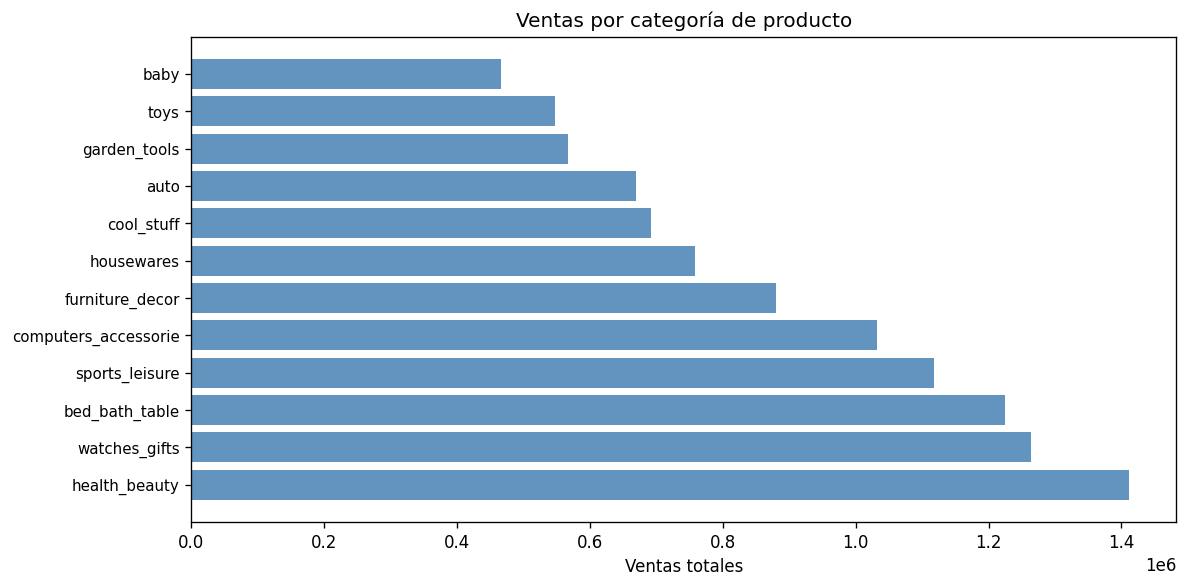

In [ ]:
import re
from pathlib import Path
from IPython.display import Image, display

OUT = Path("output")
OUT.mkdir(exist_ok=True)

respuesta_grafica = ask_bi(db, "Muéstrame un gráfico de ventas por categoría de producto.", provider="deepseek")
print(respuesta_grafica)

# Extraer y mostrar la imagen si la respuesta contiene una ruta .png
img_match = re.search(r'([\w\-./:]+\.(?:png|jpg|jpeg|webp))', respuesta_grafica, re.IGNORECASE)
if img_match:
    img_path = Path(img_match.group(1))
    if not img_path.exists() and not img_path.is_absolute():
        img_path = OUT / img_path.name
    if img_path.exists():
        display(Image(filename=str(img_path)))

### Nota
Cuando pidas gráficas por lenguaje natural, el agente devuelve la ruta del archivo generado (por ejemplo en `output/`). Si quieres visualizarlo en notebook, usa `IPython.display.Image`.

## 6. Chatbot con log + render automático de gráficas (VFS)

Esta sección agrega una experiencia tipo chat con trazabilidad persistente en **VFS local**:
- Guarda cada interacción en `vfs/bi_chat_memory.duckdb` (tabla `bi_chat_log`)
- Campos: `timestamp`, `input`, `output`, `image_path`, `provider`
- Si el agente devuelve una ruta de imagen (`.png/.jpg/.jpeg/.webp`), la muestra automáticamente en el notebook.

In [ ]:
import json
import re
from datetime import datetime
from pathlib import Path

import duckclaw
from IPython.display import Image, display
from duckclaw.bi import ask_bi

# Persistencia en VFS local
VFS_DIR = REPO_ROOT / 'vfs'
VFS_DIR.mkdir(parents=True, exist_ok=True)
CHAT_DB_PATH = VFS_DIR / 'bi_chat_memory.duckdb'
chat_db = duckclaw.DuckClaw(str(CHAT_DB_PATH))

chat_db.execute("""
CREATE TABLE IF NOT EXISTS bi_chat_log (
    created_at TEXT,
    input_text TEXT,
    output_text TEXT,
    image_path TEXT,
    provider TEXT
)
""")

MAX_CHAT_ROWS = 1000
AUTO_PRUNE = True

print(f'🗄️ VFS chat memory: {CHAT_DB_PATH}')
print(f'🧹 Rotación automática: {AUTO_PRUNE} (máx {MAX_CHAT_ROWS} filas)')

CHAT_LOG = []

def _esc(s: str) -> str:
    return str(s).replace("'", "''")

def _extract_image_path(text: str):
    if not text:
        return None
    pattern = r'([\w\-./]+\.(?:png|jpg|jpeg|webp))'
    m = re.search(pattern, text, flags=re.IGNORECASE)
    if not m:
        return None
    raw = m.group(1)
    p = Path(raw)
    candidates = [p, Path.cwd() / p, Path.cwd().parent / p]
    for c in candidates:
        if c.exists():
            return c.resolve()
    return None

def _query_json(sql: str):
    raw = chat_db.query(sql)
    return json.loads(raw) if isinstance(raw, str) else (raw or [])

def chat_log_count() -> int:
    rows = _query_json('SELECT COUNT(*) AS n FROM bi_chat_log')
    return int(rows[0]['n']) if rows else 0

def prune_chat_log(keep_last: int = MAX_CHAT_ROWS):
    keep_last = int(keep_last)
    if keep_last <= 0:
        return 0
    total = chat_log_count()
    if total <= keep_last:
        return 0
    rows = _query_json(
        f"SELECT created_at FROM bi_chat_log ORDER BY created_at DESC LIMIT 1 OFFSET {keep_last - 1}"
    )
    if not rows:
        return 0
    cutoff = rows[0]['created_at']
    before = total
    chat_db.execute(
        f"DELETE FROM bi_chat_log WHERE created_at < '{_esc(cutoff)}'"
    )
    after = chat_log_count()
    return max(before - after, 0)

def chat_log_stats():
    total = chat_log_count()
    provider_rows = _query_json(
        'SELECT provider, COUNT(*) AS n FROM bi_chat_log GROUP BY provider ORDER BY n DESC'
    )
    latest_rows = _query_json(
        'SELECT created_at FROM bi_chat_log ORDER BY created_at DESC LIMIT 1'
    )
    latest = latest_rows[0]['created_at'] if latest_rows else ''
    return {
        'total_rows': total,
        'providers': provider_rows,
        'latest_timestamp': latest,
    }

def _save_chat_record(question: str, answer: str, image_path: str, provider: str):
    ts = datetime.now().isoformat(timespec='seconds')
    chat_db.execute(
        'INSERT INTO bi_chat_log (created_at, input_text, output_text, image_path, provider) ' +
        f"VALUES ('{_esc(ts)}', '{_esc(question)}', '{_esc(answer)}', '{_esc(image_path)}', '{_esc(provider)}')"
    )
    if AUTO_PRUNE:
        prune_chat_log(MAX_CHAT_ROWS)

def load_chat_log(limit: int = 200):
    return _query_json(
        'SELECT created_at AS timestamp, input_text AS input, output_text AS output, image_path, provider ' +
        f"FROM bi_chat_log ORDER BY created_at DESC LIMIT {int(limit)}"
    )

def ask_bi_with_log(question: str, provider: str = 'groq', save_traces: bool = False, send_to_langsmith: bool = False):
    answer = ask_bi(db, question, provider=provider, save_traces=save_traces, send_to_langsmith=send_to_langsmith)
    image = _extract_image_path(answer)
    image_str = str(image) if image else ''

    record = {
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'input': question,
        'output': answer,
        'image_path': image_str,
        'provider': provider,
    }
    CHAT_LOG.append(record)
    _save_chat_record(question, answer, image_str, provider)
    return answer, image


🗄️ VFS chat memory: /Users/juanjosearevalocamargo/Desktop/duckclaw/vfs/bi_chat_memory.duckdb
🧹 Rotación automática: True (máx 1000 filas)


In [ ]:
# Chat interactivo con render automático de gráfica (Groq, DeepSeek o MLX)
PROVIDER = 'deepseek'  # 'groq', 'deepseek' o 'mlx' (MLX requiere: pm2 start ecosystem.config.cjs)
print(f"🤖 BI Chat Pro ({PROVIDER}) listo. Escribe tu pregunta (o 'salir').")
while True:
    q = input("👤 Tú: ").strip()
    if not q:
        continue
    if q.lower() in ('salir', 'exit', 'quit', 'q'):
        print("👋 Fin de la sesión.")
        break
    print("👤 Tú:", q)

    ans, img = ask_bi_with_log(q, provider=PROVIDER, save_traces=True, send_to_langsmith=True)
    print("📊 BI:", ans)

    if img is not None:
        print(f"🖼️ Mostrando gráfica: {img}")
        display(Image(filename=str(img)))

    print('-' * 90)


🤖 BI Chat Pro (deepseek) listo. Escribe tu pregunta (o 'salir').
👋 Fin de la sesión.


## 7. Trazas para entrenamiento GRPO

Con `save_traces=True` en `ask_bi`, cada traza se guarda en:
- **`train/grpo_olist_traces.jsonl`**: trazas crudas (append)
- **`train/grpo_olist_rewarded.jsonl`**: trazas con reward (append automático, listas para entrenar)

Opcional: `send_to_langsmith=True` para enviar a LangSmith (requiere `LANGCHAIN_API_KEY` en `.env`).

**`load_grpo_traces()`** y **`trace_stats()`** usan por defecto `grpo_olist_rewarded.jsonl` (con rewards).

In [ ]:
# save_traces=True guarda en train/grpo_olist_traces.jsonl
# send_to_langsmith=True envía a LangSmith (LANGCHAIN_API_KEY)
# respuesta = ask_bi(db, "¿Mejores vendedores?", provider=PROVIDER, save_traces=True, send_to_langsmith=True)

from duckclaw.bi import load_grpo_traces, trace_stats

stats = trace_stats()
print("Trazas GRPO:", stats)
# load_grpo_traces(limit=5)  # Ver últimas 5 trazas

Trazas GRPO: {'total': 19, 'providers': {'groq': 1, 'mlx': 8, 'deepseek': 10}, 'path': '/Users/juanjosearevalocamargo/Desktop/duckclaw/train/grpo_olist_traces.jsonl'}


### Clasificación de recompensas (batch)

`classify_traces()` reprocesa todo `grpo_olist_traces.jsonl` y reescribe `grpo_olist_rewarded.jsonl`. Útil para recalcular rewards o filtrar por `min_reward`. Las trazas nuevas se clasifican automáticamente al guardar.

In [ ]:
from duckclaw.rl import classify_traces, load_rewarded_traces, convert_to_grpo_groups

rewarded, stats = classify_traces()
print("Clasificación:", stats)

# Convertir a formato grupos GRPO (para Unsloth)
groups, group_stats = convert_to_grpo_groups()
print("Grupos GRPO:", group_stats)
# Usar train/grpo_olist_groups.jsonl para entrenar en Unsloth

# Cargar trazas con reward >= 0.3 (formato flat)
train_data = load_rewarded_traces(min_reward=0.3)
print(f"Trazas flat (reward>=0.3): {len(train_data)}")

Clasificación: {'input_path': '/Users/juanjosearevalocamargo/Desktop/duckclaw/train/grpo_olist_traces.jsonl', 'output_path': '/Users/juanjosearevalocamargo/Desktop/duckclaw/train/grpo_olist_rewarded.jsonl', 'total_input': 19, 'total_output': 19, 'filtered': 0, 'min_reward': -0.2, 'max_reward': 1.0, 'avg_reward': 0.4421052631578948}
Trazas para entrenar (reward>=0.3): 9


In [ ]:
# Ver/exportar log de conversación desde VFS
import pandas as pd

stats = chat_log_stats()
print('📈 Stats:', stats)

log_df = pd.DataFrame(load_chat_log(limit=500))
display(log_df.head(20))

# Limpieza manual opcional
# deleted = prune_chat_log(keep_last=300)
# print(f'🧹 Filas eliminadas: {deleted}')

# Exportar snapshot opcional
# Path('output').mkdir(exist_ok=True)
# log_df.to_csv('output/chat_log_vfs.csv', index=False)


📈 Stats: {'total_rows': 21, 'providers': [{'provider': 'mlx', 'n': '11'}, {'provider': 'deepseek', 'n': '10'}], 'latest_timestamp': '2026-02-26T15:07:43'}


,timestamp,input,output,image_path,provider
0,2026-02-26T15:07:43,haz un gràfico con las ventas por mes del 2017,<thought>\nLa herramienta se ejecutó correctam...,/Users/juanjosearevalocamargo/Desktop/duckclaw...,deepseek
1,2026-02-26T15:07:16,que tablas hay disponibles?,"Tablas disponibles: olist_customers, olist_geo...",,deepseek
2,2026-02-26T15:06:59,haz un diagrama de torta con el top 5 de categ...,<thought>\nLa herramienta se ejecutó correctam...,/Users/juanjosearevalocamargo/Desktop/duckclaw...,deepseek
3,2026-02-26T15:03:09,haz un diagrama de torta con las top 5 categor...,<thought>\nHe generado un gráfico de barras de...,/Users/juanjosearevalocamargo/Desktop/duckclaw...,deepseek
4,2026-02-26T14:59:41,pasa un diagrama de torta con el top 5 de cate...,<thought>\nHe generado un gráfico de barras co...,/Users/juanjosearevalocamargo/Desktop/duckclaw...,deepseek
5,2026-02-26T14:58:52,haz una grafica con las ventas por med de 2017,<answer>\nHe generado la gráfica de ventas por...,/Users/juanjosearevalocamargo/Desktop/duckclaw...,deepseek
6,2026-02-26T14:58:27,que tablas hay disponibles?,<answer>\nEn el dataset Olist hay disponibles ...,,deepseek
7,2026-02-26T14:51:09,haz una gràfica de ventas por mes en 2018,"Resumen: 96,478 pedidos, ventas totales 15,419...",,deepseek
8,2026-02-26T14:50:33,cual es el mejor vendedor?,<thought>\n1. Análisis del resultado: Se obtuv...,,deepseek
9,2026-02-26T14:49:56,que tablas hay disponibles?,"Resumen: 96,478 pedidos, ventas totales 15,419...",,deepseek


In [ ]:
# Mantenimiento rápido del VFS
print('Antes:', chat_log_stats())
deleted = prune_chat_log(keep_last=500)
print(f'🧹 Eliminadas: {deleted}')
print('Después:', chat_log_stats())


Antes: {'total_rows': 21, 'providers': [{'provider': 'mlx', 'n': '11'}, {'provider': 'deepseek', 'n': '10'}], 'latest_timestamp': '2026-02-26T15:07:43'}
🧹 Eliminadas: 0
Después: {'total_rows': 21, 'providers': [{'provider': 'mlx', 'n': '11'}, {'provider': 'deepseek', 'n': '10'}], 'latest_timestamp': '2026-02-26T15:07:43'}


## 8. Exportar a DataLake listo para Fabric

**Sincronizar con OneLake:** `pip install -e ".[fabric]"` (azure-storage-file-datalake, azure-identity). Requiere `az login` y FABRIC_WORKSPACE_ID + FABRIC_LAKEHOUSE_ID en .env.

In [ ]:
db.create_datalake(duckclaw.get_datalake_path())
print(f"DataLake exportado a: {duckclaw.get_datalake_path()}")

DataLake exportado a: /Users/juanjosearevalocamargo/Desktop/duckclaw/datalake
